# Figure 2: Structure functions from a 2D simulation

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.ticker as ticker
import pyturbo_sf as psf
import pyproj
import numpy as np
from matplotlib.gridspec import GridSpec
linewidth = 2
fontsize = 12
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['savefig.dpi'] = 150
plt.rc('font', family='serif')
import gc

# Load the CROCO Dataset

In [2]:
path_data = '/home/aayouche/Downloads'
idt = 10
dsh = xr.open_dataset(path_data+'/'+'surface.nc')
dsg = xr.open_dataset(path_data+'/'+'GOM_150_grd.nc')

lon = dsg.lon_rho
lat = dsg.lat_rho

lon_center = np.nanmin(lon)
utm_zone = int(1 + (lon_center + 180.0) / 6.0)

# Create the projection
proj = pyproj.Proj(proj='utm', zone=utm_zone, ellps='WGS84', datum='WGS84')

x, y = proj(lon.values, lat.values) 

X = 0.25*(x[1:,1:] + x[1:,:-1] + x[:-1,:-1] + x[:-1,1:])
Y = 0.25*(y[1:,1:] + y[1:,:-1] + y[:-1,:-1] + y[:-1,1:])


u = np.array(dsh.u.isel(s_rho=0,time=idt))
u = 0.5*(u[1:,:] + u[:-1,:])
v = np.array(dsh.v.isel(s_rho=0,time=idt))
v = 0.5*(v[:,1:] + v[:,:-1])

dudx = np.gradient(u,axis=1)/(2*150.)
dvdx = np.gradient(v,axis=1)/(2*150.)
dudy = np.gradient(u,axis=0)/(2*150.)
dvdy = np.gradient(v,axis=0)/(2*150.)

adv_u = u*dudx + v*dudy

adv_v = v*dudx + v*dvdy

temp = np.array(dsh.temp.isel(s_rho=0,time=idt))

temp = 0.25*(temp[1:,1:] + temp[1:,:-1] + temp[:-1,:-1] + temp[:-1,1:])
f = 1.0e-4
vort = dvdx - dudy + f
dvortdx = np.gradient(vort,axis=1)/(2*150.)
dvortdy = np.gradient(vort,axis=0)/(2*150.)

adv_vort = u*dvortdx + v*dvortdy

gc.collect()

70

In [3]:
gc.collect()

0

# Format Dataset

In [4]:
# Create the xarray dataset
ds = xr.Dataset({
    'u': (['y', 'x'], u),
    'v': (['y', 'x'], v),
    'adv_u':(['y', 'x'], adv_u),
    'adv_v':(['y', 'x'], adv_v),
    'temperature':(['y', 'x'], temp),
    'vort':(['y', 'x'], vort),
    'adv_vort':(['y', 'x'], adv_vort),


}, coords={
    'x': (['y', 'x'], X),
    'y': (['y', 'x'], Y)
})



In [5]:
ds

<xarray.Dataset> Size: 69MB
Dimensions:      (y: 1537, x: 1025)
Coordinates:
    y            (y, x) float64 13MB 3.039e+06 3.039e+06 ... 3.267e+06 3.267e+06
    x            (y, x) float64 13MB 3.542e+05 3.544e+05 ... 5.086e+05 5.088e+05
Data variables:
    u            (y, x) float32 6MB -0.3907 -0.4025 -0.4012 ... 0.01855 0.01787
    v            (y, x) float32 6MB 0.08256 0.09225 0.1009 ... 0.0189 0.01809
    adv_u        (y, x) float32 6MB 1.877e-05 1.042e-05 ... 2.56e-07 9.305e-08
    adv_v        (y, x) float32 6MB -6.296e-06 -6.236e-06 ... -3.306e-07
    temperature  (y, x) float32 6MB 25.06 25.06 25.06 ... 20.97 20.97 20.97
    vort         (y, x) float32 6MB 9.174e-05 9.375e-05 ... 7.981e-05 8.993e-05
    adv_vort     (y, x) float32 6MB -6.696e-09 -4.602e-09 ... 7.135e-10

In [6]:
gc.collect()

30

# Calculate ISOTROPIC Longitudinal, Transverse SF and vorticity

In [8]:
%%time

bin_r = np.logspace(np.log10(150.), np.log10(153.0e3), 12)
bins = {
    'r': bin_r,
}
iso_sf_lon = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","v"],
    order=2,
    bins=bins,
    fun='longitudinal',
    bootsize={'y':96,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=0.05,
    window_size_r=8,
    window_size_theta=10,
    n_jobs=-1,
    backend='loky',
    seed=42
)

gc.collect()

iso_sf_trans = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","v"],
    order=2,
    bins=bins,
    fun='transverse',
    bootsize={'y':96,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=0.05,
    window_size_r=8,
    window_size_theta=10,
    n_jobs=-1,
    backend='loky',
    seed=42
)

gc.collect()

iso_sf_vort = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["vort"],
    order=2,
    bins=bins,
    fun='scalar',
    bootsize={'y':96,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=0.05,
    window_size_r=8,
    window_size_theta=10,
    n_jobs=-1,
    backend='loky',
    seed=42
)

Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 96, 'x': 64}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: longitudinal
Variables: ['u', 'v'], Order: 2
Confidence level: 0.95


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 12 bootstraps
Processing spacing 2 with 12 bootstraps
Processing spacing 4 with 12 bootstraps
Processing spacing 8 with 12 bootstraps
Processing spacing 16 with 12 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 580700160
Bins with points: 11/11
Marked 11 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP
All bins have converged or reached max bootstraps!

FINAL CONVERGENCE STATISTICS:
  Total bins with data (>10 points): 11
  Converged bins: 11
  Unconverged bins: 0
  Bins at max bootstraps: 0

Creating output dataset...
ISOTROPIC SF COMPLETED SUCCESSFULLY!
Dimensions ('y', 'x') are already in the e

# Calculate Isotropic advective-SF $\delta u.\delta ADV$

In [9]:
%%time

bin_r = np.logspace(np.log10(150.), np.log10(153.0e3), 12)

bins = {
    'r': bin_r,
}
iso_sf_adv = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","v","adv_u","adv_v"],
    order=1,
    bins=bins,
    fun='advective',
    bootsize={'y':96,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=1.0e-8,
    window_size_r=8,
    window_size_theta=10,
    n_jobs=-1,
    backend='loky',
    seed=42
)



Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 96, 'x': 64}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: advective
Variables: ['u', 'v', 'adv_u', 'adv_v'], Order: 1
Confidence level: 0.95


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 12 bootstraps
Processing spacing 2 with 12 bootstraps
Processing spacing 4 with 12 bootstraps
Processing spacing 8 with 12 bootstraps
Processing spacing 16 with 12 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 580700160
Bins with points: 11/11
Marked 2 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 9 unconverged bins
Grouped unconverged bins into 4 groups

Processing 2 bins with step size 40 in density quartile 3
  Bin 2 CONVERGED with std 0.000000

Processing 1 bins with step size 40 in density quartile 2

Processing 1 bins with step size 40 in density quartile 1


# Calculate Isotropic $\delta \omega_{z} * \delta ADV_{\omega_{z}}$

In [10]:
%%time
bin_r = np.logspace(np.log10(150.), np.log10(153.0e3), 12)

bins = {
    'r': bin_r,
}
iso_sf_adv_vort = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["vort","adv_vort"],
    order=(1,1),
    bins=bins,
    fun='scalar_scalar',
    bootsize={'y':96,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=1.0e-14,
    window_size_r=8,
    window_size_theta=10,
    n_jobs=-1,
    backend='loky',
    seed=42
)



Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 96, 'x': 64}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: scalar_scalar
Variables: ['vort', 'adv_vort'], Order: (1, 1)
Confidence level: 0.95


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 12 bootstraps
Processing spacing 2 with 12 bootstraps
Processing spacing 4 with 12 bootstraps
Processing spacing 8 with 12 bootstraps
Processing spacing 16 with 12 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 580700160
Bins with points: 11/11
Marked 5 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 6 unconverged bins
Grouped unconverged bins into 4 groups

Processing 2 bins with step size 40 in density quartile 3
  Bin 2 CONVERGED with std 0.000000

Processing 1 bins with step size 40 in density quartile 2

Processing 1 bins with step size 40 in density quartile 1

# Calculate Isotropic $SF_{LLL}$ and $SF_{L\omega\omega}$

In [11]:
%%time

bin_r = np.logspace(np.log10(150.), np.log10(153.0e3), 12)
bins = {
    'r': bin_r,
}
iso_sf_lon_3rd = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","v"],
    order=3,
    bins=bins,
    fun='longitudinal',
    bootsize={'y':96,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=1.0e-8,
    window_size_r=8,
    window_size_theta=10,
    n_jobs=-1,
    backend='loky',
    seed=42
)

gc.collect()

iso_sf_lon_vort = psf.get_isotropic_sf_2d(
    ds=ds,
    variables_names=["u","v","vort"],
    order=(1,2),
    bins=bins,
    fun='longitudinal_scalar',
    bootsize={'y':96,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=40,
    convergence_eps=1.0e-8,
    window_size_r=8,
    window_size_theta=10,
    n_jobs=-1,
    backend='loky',
    seed=42
)

Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 96, 'x': 64}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16]

STARTING ISOTROPIC_SF WITH FUNCTION TYPE: longitudinal
Variables: ['u', 'v'], Order: 3
Confidence level: 0.95


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 12 bootstraps
Processing spacing 2 with 12 bootstraps
Processing spacing 4 with 12 bootstraps
Processing spacing 8 with 12 bootstraps
Processing spacing 16 with 12 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 580700160
Bins with points: 11/11

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 11 unconverged bins
Grouped unconverged bins into 5 groups

Processing 1 bins with step size 40 in density quartile 4

Processing 3 bins with step size 40 in density quartile 3

Processing 1 bins with step size 40 in density quartile 2

Processing 1 bins with step size 40 in density quartile 1

Processing 5 bins with step size 

# Plot Figure 2

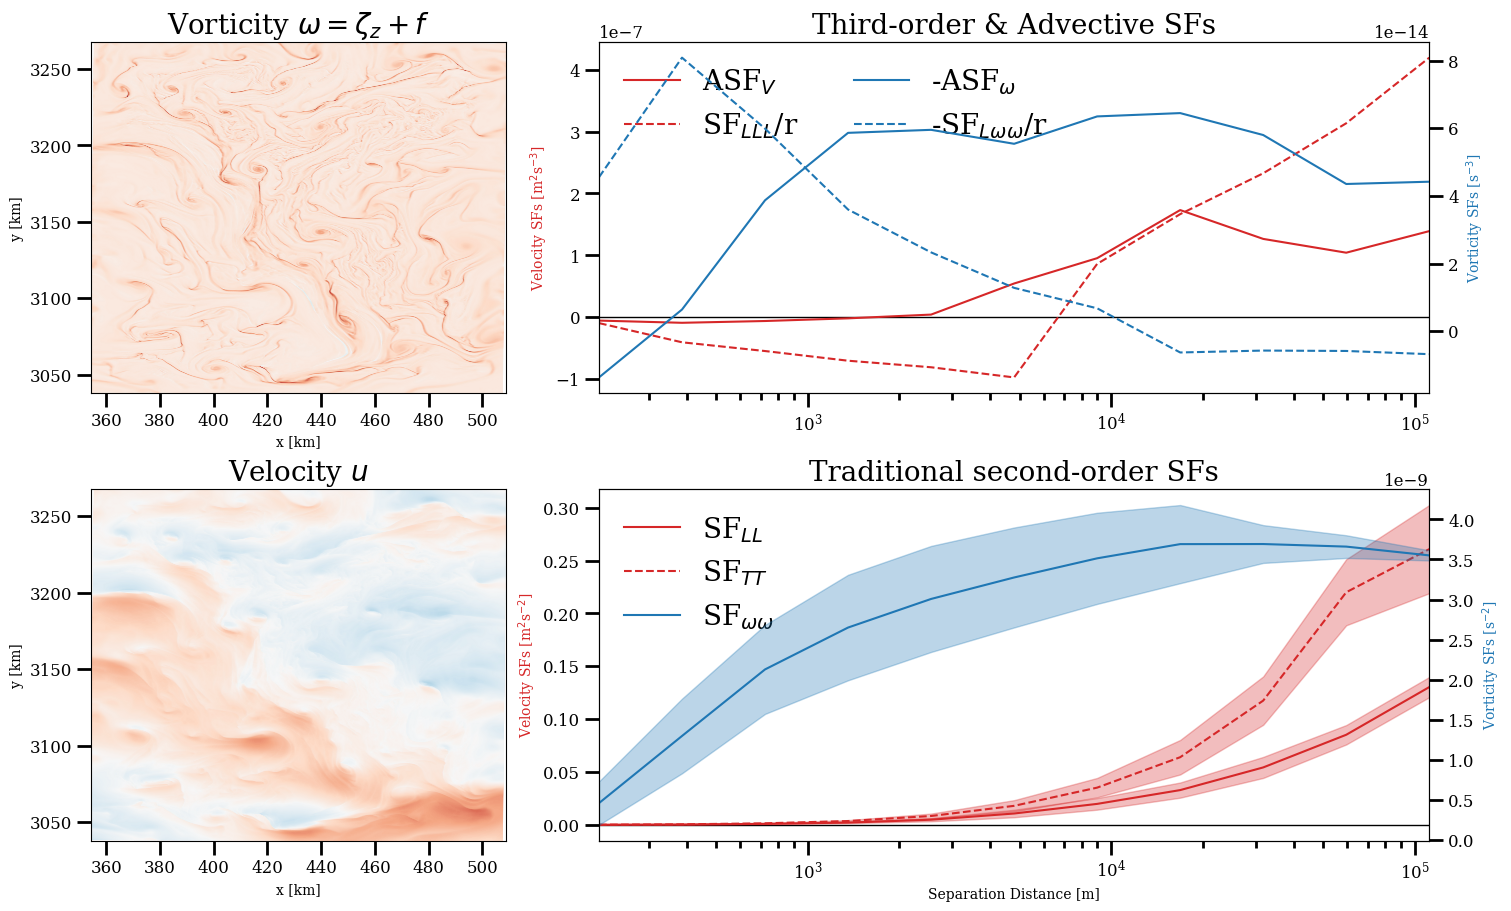

In [12]:


colors = plt.cm.Paired(np.linspace(0, 1, 12))

fig = plt.figure(layout="constrained", figsize=(15,9))

gs = GridSpec(2,3, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[0, 1:])
ax3right = ax3.twinx()
ax4 = fig.add_subplot(gs[1, 1:], sharex=ax3)
ax4right = ax4.twinx()

q_map = ax1.pcolormesh(ds.x/1e3, ds.y/1e3, ds.vort, cmap="RdBu_r", vmin=-8.0e-4, vmax=8.0e-4,shading='gouraud')

ax1.set_xlabel("x [km]")
ax1.set_ylabel("y [km]")
ax1.set_title("Vorticity $\omega = \zeta_{z} + f$", fontsize=20)

u_map = ax2.pcolormesh(ds.x/1e3, ds.y/1e3, ds.u, cmap="RdBu_r", vmin=-2, vmax=2,shading='gouraud')

ax2.set_xlabel("x [km]")
ax2.set_ylabel("y [km]")
ax2.set_title("Velocity $u$", fontsize=20)

lns1 = ax3.semilogx(
    iso_sf_adv.r, iso_sf_adv.sf, label="ASF$_V$", color='tab:red',
)

lns2 = ax3right.semilogx(
    iso_sf_adv_vort.r, iso_sf_adv_vort.sf, label="-ASF$_{\omega}$", color='tab:blue',
)

lns3 = ax3.semilogx(iso_sf_lon_3rd.r, iso_sf_lon_3rd.sf/iso_sf_lon_3rd.r, label="SF$_{LLL}$/r", color='tab:red', linestyle="dashed")


lns4 = ax3right.semilogx(iso_sf_lon_vort.r, -iso_sf_lon_vort.sf/iso_sf_lon_vort.r, label="-SF$_{L\omega\omega}$/r", color='tab:blue', linestyle="dashed")

ax3.hlines(0, iso_sf_lon.r.min(), iso_sf_lon.r.max(), lw=1, color="black",zorder=0)
ax3.set_ylabel("Velocity SFs [m$^2$s$^{-3}$]", color='tab:red')
# ax3.legend(ncol=1, loc="upper left",frameon=False, fontsize=20)
ax3.set_xlim(iso_sf_lon.r.min(), iso_sf_lon.r.max())
#ax3.set_ylim(-4,6)
ax3.set_title('Third-order & Advective SFs', fontsize=20)
#ax3right.set_ylim(-4*10,6*10)
ax3right.set_ylabel("Vorticity SFs [s$^{-3}$]", color='tab:blue')
# ax3right.legend(ncol=1, loc="upper right",frameon=False, fontsize=20)

lns = lns1+lns3+lns2+lns4
labs = [l.get_label() for l in lns]
ax3.legend(lns, labs, frameon=False, fontsize=20,ncols=2)

lns1 = ax4.semilogx(
    iso_sf_lon.r, iso_sf_lon.sf, label="SF$_{LL}$", color='tab:red',
)
ax4.fill_between(iso_sf_lon.r, iso_sf_lon.ci_lower,iso_sf_lon.ci_upper, color='tab:red', alpha=0.3)

lns2 = ax4right.semilogx(
    iso_sf_vort.r, iso_sf_vort.sf, label="SF$_{\omega \omega}$", color='tab:blue',
)
ax4right.fill_between(iso_sf_vort.r, iso_sf_vort.ci_lower,iso_sf_vort.ci_upper, color='tab:blue', alpha=0.3)
lns3 = ax4.semilogx(iso_sf_trans.r, iso_sf_trans.sf, label="SF$_{TT}$", color='tab:red', linestyle="dashed")
ax4.fill_between(iso_sf_trans.r, iso_sf_trans.ci_lower,iso_sf_trans.ci_upper, color='tab:red', alpha=0.3)
ax4.hlines(0, iso_sf_lon.r.min(), iso_sf_lon.r.max(), lw=1, color="black",zorder=0)

ax4.set_ylabel("Velocity SFs [m$^2$s$^{-2}$]", color='tab:red')
# ax4.legend(ncol=1, loc="upper left",frameon=False, fontsize=20)
ax4.set_xlim(iso_sf_lon.r.min(), iso_sf_lon.r.max())
#ax4.set_ylim(-2,6)
ax4.set_title('Traditional second-order SFs', fontsize=20)
#ax4right.set_ylim(-2*50,6*50)
ax4right.set_ylabel("Vorticity SFs [s$^{-2}$]", color='tab:blue')
# ax4right.legend(ncol=1, loc="upper center",frameon=False, fontsize=20)
ax4.set_xlabel("Separation Distance [m]")

lns = lns1+lns3+lns2
labs = [l.get_label() for l in lns]
ax4.legend(lns, labs, frameon=False, fontsize=20)

plt.savefig('../figs/fig2.png',dpi=300,bbox_inches='tight')

